In [1]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import Callback
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import matplotlib.pyplot as plt

class EarlyStoppingLossDiff(Callback):
    def __init__(self, patience=1, min_loss_diff=0.01):
        super(EarlyStoppingLossDiff, self).__init__()
        self.patience = patience
        self.min_loss_diff = min_loss_diff
        self.wait = 0
        self.stopped_epoch = 0
        self.previous_loss = None
        
    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('loss')
        
        if self.previous_loss is not None:
            loss_diff = abs(current_loss - self.previous_loss)
            
            if loss_diff < self.min_loss_diff:
                self.wait += 1
                if self.wait >= self.patience:
                    self.stopped_epoch = epoch
                    self.model.stop_training = True
                    print(f"\nEarly stopping triggered at epoch {epoch + 1} due to small loss difference: {loss_diff:.6f}")
            else:
                self.wait = 0
        
        self.previous_loss = current_loss

In [2]:
df = pd.read_csv('BostonHousing.csv')
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nDataset info:')
print(df.info())
print('\nStatistical summary:')
print(df.describe())

Dataset shape: (506, 14)

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 n

In [3]:
X = df.iloc[:, 0:13]  # All features (columns 0-12)
y = df.iloc[:, 13]    # Target variable (medv)

In [4]:
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Feature columns:', list(X.columns))

Features shape: (506, 13)
Target shape: (506,)
Feature columns: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = Sequential([
    Dense(8, activation='relu', input_dim=13),
    Dense(7, activation='relu'),
    Dense(9, activation='relu'),
    Dense(5, activation='relu'),
    Dense(1, activation='linear')
])

c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mse']
)

print('\nModel architecture:')
model.summary()

early_stopping_callback = EarlyStoppingLossDiff(patience=1, min_loss_diff=0.01)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=20,
    verbose=1,
    callbacks=[early_stopping_callback]
)


Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            63 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303 (1.18 KB)

 Trainable params: 303 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 638.9958 - mse: 638.9958 - val_loss: 581.6333 - val_mse: 581.6333
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 628.8453 - mse: 628.8453 - val_loss: 574.9431 - val_mse: 574.9431
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 621.9298 - mse: 621.9298 - val_loss: 570.0654 - val_mse: 570.0654
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 616.9659 - mse: 616.9659 - val_loss: 566.1003 - val_mse: 566.1003
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 612.6411 - mse: 612.6411 - val_loss: 561.9226 - val_mse: 561.9226
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 607.4385 - mse: 607.4385 - val_loss: 556.4178 - val_mse: 556.4178
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 600.3529 - mse: 600.3529 - val_loss: 548.4452 - val_mse: 548.4452
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 589.9473 - mse: 589.9473 - val_loss: 536.5339 - val_mse: 536.5339
Epoch 9

In [9]:
y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
mse_test = mean_squared_error(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print('\nModel Performance:')
print(f'Mean Squared Error of Test is: {mse_test:.4f} and of Train is: {mse_train:.4f}')
print(f'R² Score of Test is: {r2_test:.4f} and of Train is: {r2_train:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Model Performance:
Mean Squared Error of Test is: 20.5280 and of Train is: 20.2851
R² Score of Test is: 0.7069 and of Train is: 0.7713


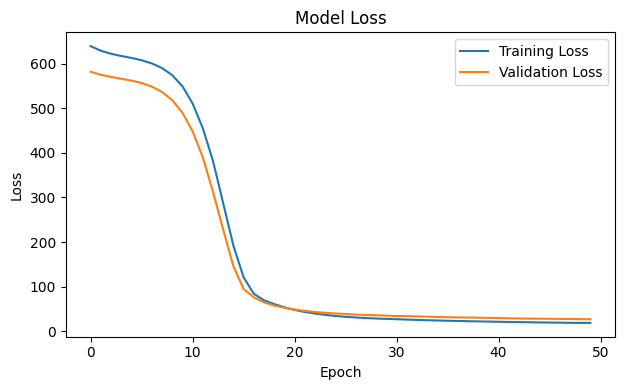

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.tight_layout()
plt.show()